# 配套实践 01-01：观察一条机器人轨迹

本练习对应基础篇第 01 章“机器人眼中的世界是什么”。我们用一段人工生成的机械臂运动数据，依次理解观测、动作、状态转移、轨迹和时间对齐。

本练习遵循一个原则：**一张图只说明一个问题**。运行每个代码单元后，请先观察图片，再阅读图片下方的解释。

<a href="https://qi-robotics.github.io/robot-world-model-tutorial/basics/01-robot-view-of-the-world/" target="_blank">在新标签页打开课程正文</a>

预计时间：10～15 分钟。不需要 GPU，也不需要下载外部数据。

## 使用方法

按照从上到下的顺序运行单元格。点击代码单元格左侧的运行按钮，或者按 Shift+Enter。这里的位置和动作只用于解释概念，不代表真实机器人的运动精度。

In [1]:
import numpy as np  # 导入 NumPy，用于创建数组和进行数值计算
import matplotlib.pyplot as plt  # 导入 Matplotlib，用于绘制教学图像

plt.rcParams["figure.dpi"] = 110  # 提高图片清晰度，便于在网页中观察细节
np.set_printoptions(precision=3, suppress=True)  # 统一数组的小数显示格式
print("环境准备完成")  # 提示依赖已经成功导入

环境准备完成


## 1. 先看完整轨迹

假设机械臂沿一个方向逐步接近杯子。我们每隔 0.1 秒记录一次机械臂末端的位置。蓝点是观测，连接蓝点的线段表示位置随时间连续变化的过程。

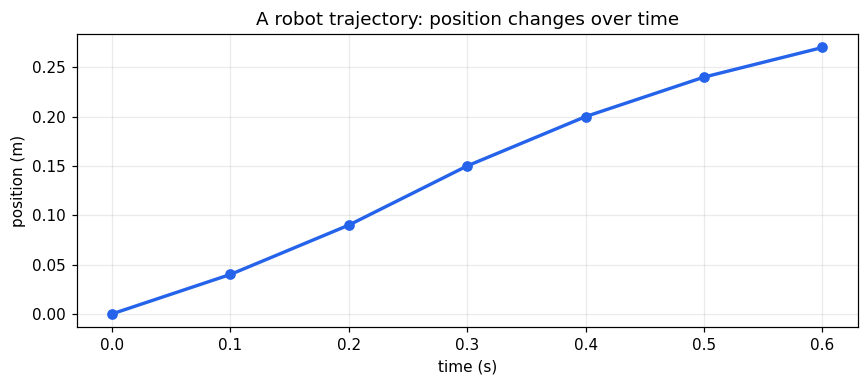

In [2]:
time = np.arange(0, 0.7, 0.1)  # 生成从 0.0 秒到 0.6 秒的七个采样时刻
observations = np.array([0.00, 0.04, 0.09, 0.15, 0.20, 0.24, 0.27])  # 记录每个时刻的末端位置
actions = np.diff(observations)  # 用相邻位置之差构造六步位移动作

fig, ax = plt.subplots(figsize=(8, 3.6))  # 创建一张宽 8 英寸、高 3.6 英寸的画布
ax.plot(time, observations, marker="o", linewidth=2.2, color="#2563eb")  # 用折线和圆点画出完整轨迹
ax.set_title("A robot trajectory: position changes over time")  # 设置图像标题
ax.set_xlabel("time (s)")  # 标明横轴表示时间，单位为秒
ax.set_ylabel("position (m)")  # 标明纵轴表示位置，单位为米
ax.set_xticks(time)  # 让横轴刻度与七个采样时刻一一对应
ax.grid(alpha=0.25)  # 添加浅色网格，方便比较各点数值
plt.tight_layout()  # 自动调整边距，避免标题和坐标文字被裁切
plt.show()  # 显示完整轨迹图

### 怎样读这张图

横轴是时间，纵轴是机械臂末端在某个方向上的位置。最左侧蓝点表示 0 秒时的位置为 0 米；最右侧蓝点表示 0.6 秒时的位置为 0.27 米。曲线逐渐上升，说明机械臂正在沿正方向移动。

图中共有 7 个蓝点，因此记录了 7 次观测。相邻的两个观测之间形成一步运动，所以只有 6 步动作。可以把它理解为：先看到当前位置，再执行一次动作，然后看到新的位置。最后一个观测之后没有继续执行动作，因此观测数量通常比连接它们的动作数量多 1。

## 2. 放大一次状态转移

整条轨迹由许多相邻的状态转移组成。下面只取第 3 个观测及其后的一步运动，避免同时展示太多信息。

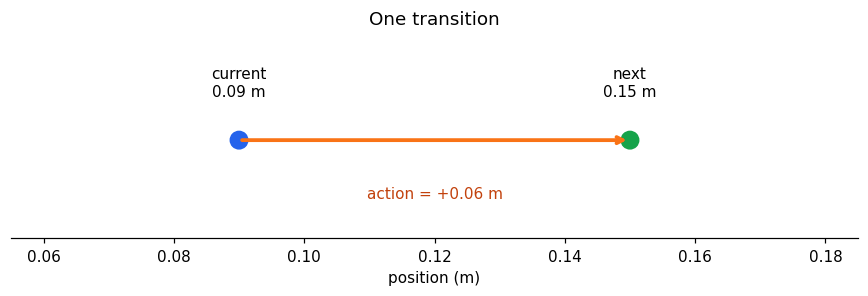

In [3]:
step = 2  # 选择第 3 个观测作为本次状态转移的起点
current_position = observations[step]  # 取出动作执行前的位置
action = actions[step]  # 取出这个时刻随后执行的位移动作
next_position = observations[step + 1]  # 取出动作执行后的下一位置

fig, ax = plt.subplots(figsize=(8, 2.8))  # 创建适合展示单次转移的横向画布
ax.scatter([current_position, next_position], [0, 0], s=130, color=["#2563eb", "#16a34a"], zorder=3)  # 分别画出当前位置和下一位置
ax.annotate("", xy=(next_position, 0), xytext=(current_position, 0),  # 指定箭头的终点和起点
            arrowprops=dict(arrowstyle="->", linewidth=2.5, color="#f97316"))  # 用橙色箭头表示执行的动作
ax.text(current_position, 0.10, f"current\n{current_position:.2f} m", ha="center")  # 标注动作执行前的位置
ax.text(next_position, 0.10, f"next\n{next_position:.2f} m", ha="center")  # 标注动作执行后的位置
ax.text((current_position + next_position) / 2, -0.13, f"action = +{action:.2f} m", ha="center", color="#c2410c")  # 在箭头下方标出动作大小
ax.set_xlim(current_position - 0.035, next_position + 0.035)  # 缩小横轴范围以突出这一步运动
ax.set_ylim(-0.22, 0.24)  # 为上下两侧的文字说明留出空间
ax.set_yticks([])  # 隐藏没有实际含义的纵轴刻度
ax.set_xlabel("position (m)")  # 标明横轴是位置，单位为米
ax.set_title("One transition")  # 设置图像标题
for side in ["left", "right", "top"]:  # 遍历不需要显示的三个边框
    ax.spines[side].set_visible(False)  # 隐藏边框，让状态转移关系更突出
plt.tight_layout()  # 自动调整画布边距
plt.show()  # 显示单次状态转移图

### 怎样读这张图

蓝点是执行动作前的观测，位置为 0.09 米；橙色箭头是机器人执行的动作，表示向正方向移动 0.06 米；绿点是动作执行后的下一次观测，位置为 0.15 米。三者组成一条完整关系：**当前观测 + 动作 → 下一观测**。

这个人工例子没有加入误差，所以 0.09 + 0.06 正好等于 0.15。真实机器人可能受到摩擦、控制延迟和测量噪声的影响，发出 0.06 米的移动命令后，实际位置变化未必恰好是 0.06 米。世界模型要学习的，正是动作与后续观测之间通常如何对应。

## 3. 从长轨迹中截取一个时间窗口

训练时不一定把整条轨迹一次交给模型，常见做法是截取连续的一小段。下面从第 2 个观测开始，选取连续 3 步动作。

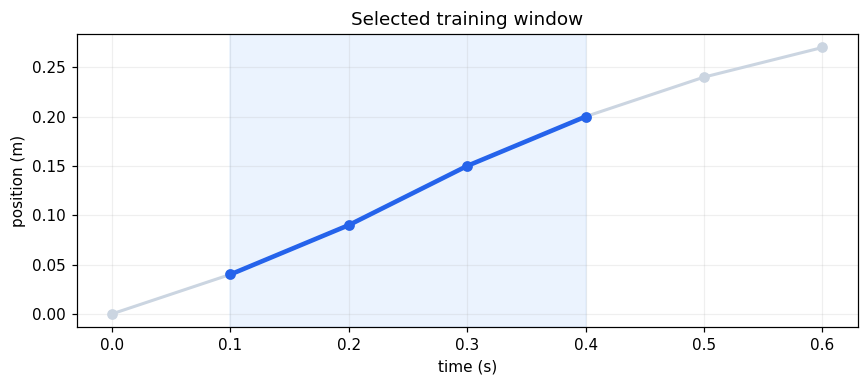

窗口内：4 个观测，3 个动作


In [4]:
window_start = 1  # 指定训练窗口从第 2 个观测开始
action_horizon = 3  # 指定窗口包含连续三步动作
window_end = window_start + action_horizon  # 计算窗口最后一个观测的索引
window_indices = np.arange(window_start, window_end + 1)  # 生成窗口内四个观测的索引
window_observations = observations[window_indices]  # 根据索引取出窗口内的观测
window_actions = actions[window_start:window_end]  # 取出连接这些观测的三步动作

fig, ax = plt.subplots(figsize=(8, 3.6))  # 创建用于对比完整轨迹和局部窗口的画布
ax.plot(time, observations, marker="o", color="#cbd5e1", linewidth=2)  # 用浅灰色画出完整轨迹作为背景
ax.plot(time[window_indices], window_observations, marker="o", color="#2563eb", linewidth=3)  # 用蓝色突出选中的连续观测
ax.axvspan(time[window_start], time[window_end], color="#dbeafe", alpha=0.55)  # 用浅蓝背景标出窗口覆盖的时间范围
ax.set_title("Selected training window")  # 设置图像标题
ax.set_xlabel("time (s)")  # 标明横轴表示时间
ax.set_ylabel("position (m)")  # 标明纵轴表示末端位置
ax.set_xticks(time)  # 让刻度与采样时间保持一致
ax.grid(alpha=0.2)  # 添加浅色网格帮助读取位置
plt.tight_layout()  # 自动调整图像边距
plt.show()  # 显示训练窗口图

print(f"窗口内：{len(window_observations)} 个观测，{len(window_actions)} 个动作")  # 输出窗口中观测和动作的数量关系

### 怎样读这张图

灰色部分仍然是完整轨迹，蓝色加粗部分是本次选中的训练窗口。窗口从 0.1 秒开始，到 0.4 秒结束。虽然我们说窗口包含 3 步动作，但图中会看到 4 个蓝点，因为每一步动作都连接前后两个观测。连续 3 步需要起点观测，再加上每一步结束后的 3 个观测，因此是 4 个观测。

这里的 `action_horizon = 3` 表示模型关注未来连续 3 步动作，而不是 3 个观测。区分“动作步数”和“观测数量”很重要，否则在切分数据时容易少取一个观测，或让动作与观测错位。

## 4. 形状正确不等于时间正确

下面故意把动作整体错开一个时间步，再比较它解释观测变化时的平均误差。图中只保留最终误差，避免把多条相似曲线叠在一起。

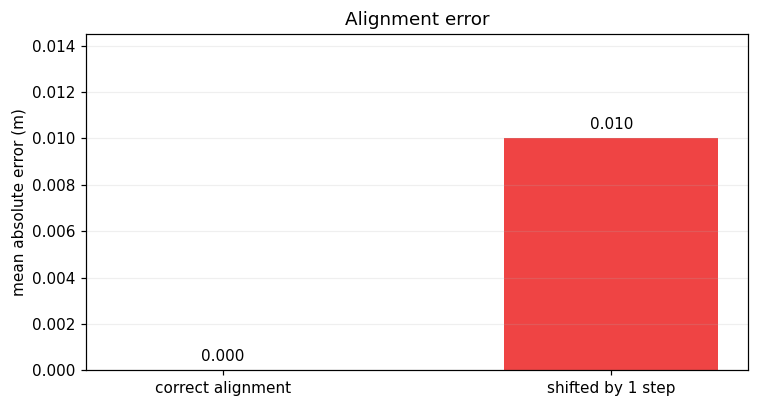

In [5]:
observed_changes = np.diff(observations)  # 计算每两个相邻观测之间的真实位置变化
correct_actions = actions.copy()  # 保留与真实变化正确对应的动作序列
shifted_actions = np.roll(actions, 1)  # 故意把动作整体错开一个时间步

correct_error = np.mean(np.abs(correct_actions - observed_changes))  # 计算正确对齐时的平均绝对误差
shifted_error = np.mean(np.abs(shifted_actions - observed_changes))  # 计算时间错位后的平均绝对误差

labels = ["correct alignment", "shifted by 1 step"]  # 准备两根柱子的文字标签
errors = [correct_error, shifted_error]  # 按照标签顺序整理两种误差
fig, ax = plt.subplots(figsize=(7, 3.8))  # 创建用于比较误差的画布
bars = ax.bar(labels, errors, color=["#16a34a", "#ef4444"], width=0.55)  # 用绿色和红色柱子表示两种对齐情况
ax.set_title("Alignment error")  # 设置图像标题
ax.set_ylabel("mean absolute error (m)")  # 标明纵轴是平均绝对误差
ax.set_ylim(0, max(errors) * 1.35 + 0.001)  # 为柱顶的数值标签预留空间
ax.bar_label(bars, labels=[f"{value:.3f}" for value in errors], padding=4)  # 在每根柱子上显示误差数值
ax.grid(axis="y", alpha=0.2)  # 添加水平网格方便比较柱高
plt.tight_layout()  # 自动调整画布边距
plt.show()  # 显示时间对齐误差图

### 怎样读这张图

绿色柱表示动作与对应的观测变化正确配对。因为本例中的动作就是由相邻位置之差得到的，所以误差为 0。红色柱表示动作整体错开一步后的结果，此时数组长度没有变化，代码仍然能够运行，但动作已经无法正确解释同一时刻的观测变化，因此误差明显增大。

这张图要说明的不是误差数值本身，而是一个数据检查原则：**只检查张量形状是不够的，还必须检查时间顺序。** 两个数组都含有 6 个数，并不代表它们在语义上正确对应。训练数据如果发生这种错位，模型学到的就会是错误的动作—结果关系。

## 练习与小结

1. 将 `action_horizon` 改为 2 或 4，重新运行第 3 节。确认蓝点数量始终比动作步数多 1。
2. 修改 `observations` 中的一个位置值，然后从头运行，观察轨迹形状和动作大小怎样变化。
3. 把 `np.roll(actions, 1)` 中的 1 改为 2，观察时间错位误差是否发生变化。

本练习建立了四个基本认识：轨迹是按时间排列的观测序列；动作连接相邻观测；训练窗口必须保持连续；数组形状正确时，时间关系仍可能出错。